Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Uploading dataset

In [ ]:
path = "Datasets/Churn_Modelling.csv"

df = pd.read_csv(path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Preprocessing

In [3]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace = True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print(df['Geography'].value_counts())
print()
print(df['Gender'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [6]:
df_new = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True, dtype=int)
df_new.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


Preparing data for training

In [14]:
# Preparing input and output columns
X = df_new.drop(columns=['Exited'])
y = df_new['Exited'].values

# Splitting for training and prediction
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [15]:
# Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [16]:
print(X_train_trf)
print(X_train_trf.shape)

[[-1.24021723  0.77986083  0.35390313 ... -0.57812007 -0.57504086
  -1.09665089]
 [ 0.75974873 -0.27382717  0.35390313 ...  1.72974448 -0.57504086
   0.91186722]
 [-1.72725557 -0.9443559  -0.3390904  ... -0.57812007 -0.57504086
  -1.09665089]
 ...
 [-0.51484098  0.87565065  1.39339343 ...  1.72974448 -0.57504086
   0.91186722]
 [ 0.73902369 -0.36961699 -1.03208393 ... -0.57812007 -0.57504086
  -1.09665089]
 [ 0.95663657 -1.32751517  0.35390313 ... -0.57812007  1.73900686
   0.91186722]]
(8000, 11)


Preparing the Neural Network

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

model1 = Sequential([
    Input(shape=(X_train_trf.shape[1],)),
    Dense(11, activation='relu'),
    Dense(6, activation='relu'),
    Dense(3, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229 (916.00 B)

 Trainable params: 229 (916.00 B)

 Non-trainable params: 0 (0.00 B)

Training the NN

In [18]:
model1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train_trf, y_train, batch_size=50, epochs=100, validation_split=0.2, verbose=1)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7472 - loss: 0.6497 - val_accuracy: 0.8119 - val_loss: 0.5783
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7923 - loss: 0.5262 - val_accuracy: 0.8119 - val_loss: 0.4646
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7931 - loss: 0.4602 - val_accuracy: 0.8194 - val_loss: 0.4253
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8061 - loss: 0.4374 - val_accuracy: 0.8281 - val_loss: 0.4143
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8134 - loss: 0.4298 - val_accuracy: 0.8313 - val_loss: 0.4103
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8155 - loss: 0.4233 - val_accuracy: 0.8363 - val_loss: 0.4032
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8278 - loss: 0.4118 - val_accuracy: 0.8425 - val_loss: 0.3911
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8408 - loss: 0.3955 - val_accu

Predicting output and accuracy

In [19]:
y_pred = model1.predict(X_test_trf)
print(y_pred)

# Preparing the 2 classes
y_pred[y_pred>0.5] = 1
y_pred[y_pred<=0.5] = 0

# Checking accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[0.10476115]
 [0.1117064 ]
 [0.02086445]
 ...
 [0.02490147]
 [0.9999536 ]
 [0.06279268]]


0.858

Plotting

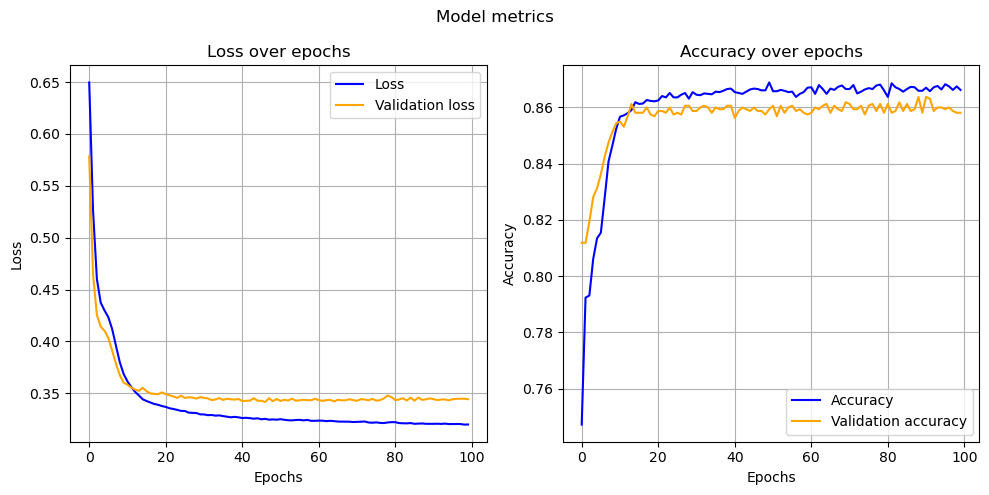

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history1.history['loss'], color='blue', label='Loss')
ax[0].plot(history1.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history1.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history1.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()

Improving the NN

In [42]:
from tensorflow.keras.layers import Dropout, BatchNormalization

# Batch normalisation and He normal weight initialisation
model2 = Sequential([
    Input(shape=(X_train_trf.shape[1],)),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(16, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(8, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    
    Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 112 (448.00 B)

In [44]:
# Early stopping
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(monitor='val_loss',
                         min_delta = 1e-4,
                         patience=20,
                         verbose=1,
                         mode='auto',
                         baseline=None,
                         restore_best_weights=True)

model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
history2 = model2.fit(X_train_trf, y_train, batch_size=50, validation_split=0.2, epochs=100, callbacks=callback)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6466 - loss: 0.6542 - val_accuracy: 0.7394 - val_loss: 0.5717
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7641 - loss: 0.5372 - val_accuracy: 0.8125 - val_loss: 0.4721
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4791 - val_accuracy: 0.8238 - val_loss: 0.4253
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8016 - loss: 0.4549 - val_accuracy: 0.8319 - val_loss: 0.4038
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8089 - loss: 0.4397 - val_accuracy: 0.8363 - val_loss: 0.3929
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8127 - loss: 0.4302 - val_accuracy: 0.8394 - val_loss: 0.3851
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8166 - loss: 0.4250 - val_accuracy: 0.8406 - val_loss: 0.3795
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8195 - loss: 0.4174 - val_accu

Predicting output and accuracy

In [45]:
from sklearn.metrics import accuracy_score

y_pred = model2.predict(X_test_trf)

# Preparing the 2 classes through different thresholds
thresholds = [i*0.1 for i in range(3, 9)]

for t in thresholds:
	y_predn = y_pred.copy()
	y_predn[y_predn>t] = 1
	y_predn[y_predn<=t] = 0

	# Checking accuracy
	print(f"Accuracy for {t:0.2f}: {accuracy_score(y_test, y_predn)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy for 0.30: 0.8435
Accuracy for 0.40: 0.861
Accuracy for 0.50: 0.8615
Accuracy for 0.60: 0.8615
Accuracy for 0.70: 0.846
Accuracy for 0.80: 0.8355


Plotting

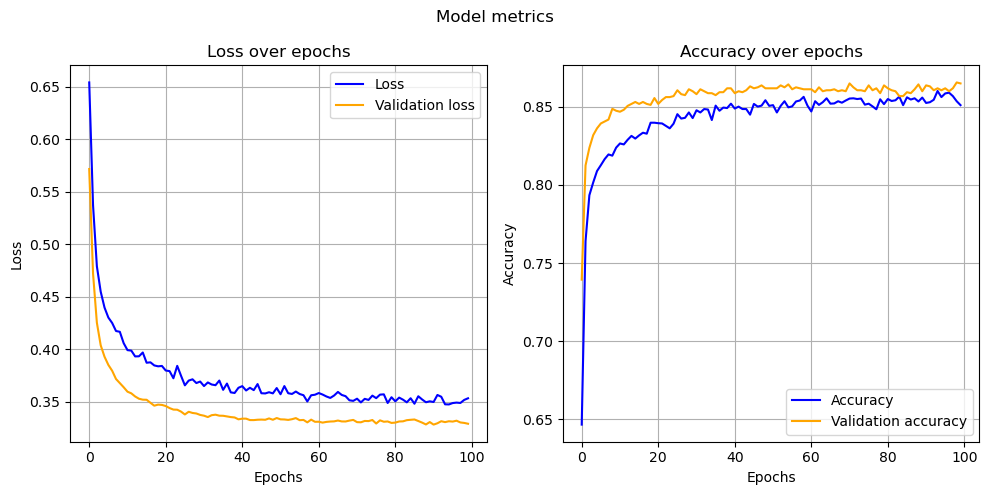

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss
ax[0].plot(history2.history['loss'], color='blue', label='Loss')
ax[0].plot(history2.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history2.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history2.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle("Model metrics")
fig.tight_layout()
plt.show()